In [13]:
import torch

# Creating A Computation Graph

For a funcrion: $z=2(a-b)+c$

Given values of a, b and c we can define function as below:

In [14]:
! pip install graphviz torchviz

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [15]:
def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z

Not we can use the functon as:

In [16]:
# Note that we have defined scalar as: torch.tensor(<value>)
print('Scalar Inputs:', compute_z(
    torch.tensor(1),
    torch.tensor(2),
    torch.tensor(3),
))

print('Rank 1 Inputs:', compute_z(
    torch.tensor([1]),
    torch.tensor([2]),
    torch.tensor([3]),
))


print('Rank 2 Inputs:', compute_z(
    torch.tensor([[1]]),
    torch.tensor([[2]]), 
    torch.tensor([[3]]))
)

Scalar Inputs: tensor(1)
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


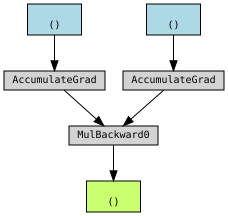

In [17]:
from torchviz import make_dot

x1 = torch.tensor(3.01, requires_grad=True)
x2 = torch.tensor(5.22, requires_grad=True)

w = torch.mul(x1, x2)

make_dot(w)

# Storing Model Update Parameters
- In pytorch, special tensor object for which gradients need to compute allows to store and update model parameters during training

- Created using `requires_grad=True`

- Note: Only tensor of `dtype` **float and complex can require gradients**.

- Is set to **false by default**.

In [18]:
a = torch.tensor(3.14, requires_grad=True)

print(a)

b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
print(b)

tensor(3.1400, requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


**Example On Calculating Gradients:**

Suppose we have an equation: $z = wx+b$

And a loss function defined over: 

$$l={ (y-z)^2 }$$

$$l={ (y- (wx + b))^2 }$$

$$l={ ((wx + b) - y)^2 }$$

For a sequence of length n:

$$l_{sum}=\sum_{i=1}^{n} (y-z)^2$$

In [19]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
x = torch.tensor([1.4])
y = torch.tensor([2.1])

z = torch.add(torch.mul(w, x), b)

# Sum can also handle a scalar
loss = (y-z).pow(2).sum()

loss.backward()
print('dL/dw : ', w.grad)
print('dL/db : ', b.grad)

dL/dw :  tensor(-0.5600)
dL/db :  tensor(-0.4000)


$$\frac{ \partial l } {\partial w} = 2(wx+b - y) x$$

$$\frac{ \partial l } {\partial b} = 2(wx+b - y)$$

In [20]:
print("dL/dW",2 * x * ((w * x + b) - y))
print("dL/db",2 * ((w * x + b) - y))

dL/dW tensor([-0.5600], grad_fn=<MulBackward0>)
dL/db tensor([-0.4000], grad_fn=<MulBackward0>)


# Implementing models based on nn.Sequential

In [21]:
from torch import nn

model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)
model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

**Resources To Explore:**
- [Choosing Activation Function](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)
- [Initializing Layer Parameters](https://pytorch.org/docs/stable/nn.init.html)
- [Applying L2 regularization](https://pytorch.org/docs/stable/optim.html)

**In the example below:**
- Initialize the weight of the first linear layer with [Xavier initialization](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.xavier_uniform_)
- Compute the L1 norm of the weight of the second linear layer

In [22]:
nn.init.xavier_uniform_(model[0].weight)
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()

**Choosing a Loss Function:**
- Using [Binary Cross Entropy Loss Function](https://www.geeksforgeeks.org/binary-cross-entropy-log-loss-for-binary-classification/)
- [Schoastic Gradient Descent](https://www.geeksforgeeks.org/ml-stochastic-gradient-descent-sgd/)
- Learning Rate of 0.001

In [23]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

**Using With nn.Module**
- Initializing weights

In [24]:
class MyModule(nn.Module):

    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2 = torch.empty(1, 2, requires_grad=True)
        nn.init.xavier_normal_(self.w2)